In [15]:
import sys
from scipy import sparse
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
import scipy.ndimage
from astropy import units as u

from scalesETC.scales import *
from scalesETC.widgets import *
from scalesETC.targs import *




%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configure SCALES and your integration times

In [16]:
scalesmode = mode_select()
guidestar = gs_select()
scalesmode #use the dropdown to select your mode!

Dropdown(description='Mode:', options=('Low-Res KLM: 2.0-5.2', 'Low-Res K: 1.95-2.45', 'Med-Res K: 1.95-2.45',…

In [32]:
sim = SCALES(scalesmode,guidestar,fullfr=True)

In [42]:
nexps = 1 #total frames to simulate
int_time = 3600*5 #integration time in seconds per frame

## Let's pass the ETC a scene!

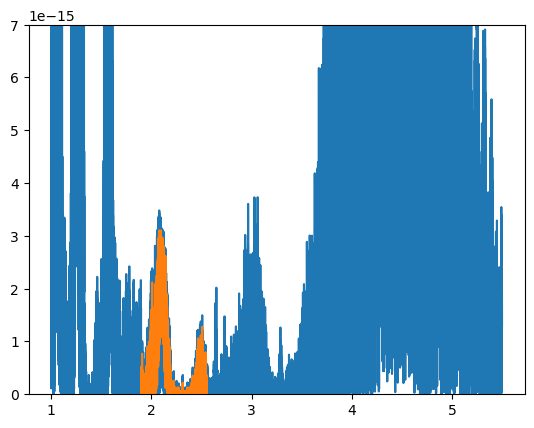

In [48]:
plan = sonora_planet(T_p=500,sg=100,rp=1.6,Lmag=18) #set Kmag, Lmag, OR Mmag to re-normalize your planet

#plan,bg = flat_mJy_target(653.*10**(-19.9/2.5)*1000.0)
scene_lowres = np.zeros([len(sim.plams),18,17]) #set up a perfect datacube to pass to the simulator (108x108 for low-res, 18x17 for med-res)
scene_lowres[:,9,8]=plan.resample(sim.plams) #add your planet to your desired pixel in the FOV

#let's check out a plot of the input spectra
plt.plot(plan.x,plan.y) #spectrally-oversampled
plt.plot(sim.plams,scene_lowres[:,9,8]) #downsampled to the input resolution expected by the simulator
plt.ylim(0,7e-15)
plt.show()

scene_lowres=scene_lowres*u.erg/u.cm/u.cm/u.s/u.um

img_seq, IFScube_seq, rlams = sim.image_and_cube(cube=scene_lowres,nexps=nexps,dit=int_time,shot_off=False,bkgsub=True)

In [61]:
img_seq, img_seq_bg, IFScube_seq, IFScube_seq_bg, rlams = sim.image_and_cube(cube=scene_lowres,nexps=nexps,dit=int_time,shot_off=False,bkgsub=False)

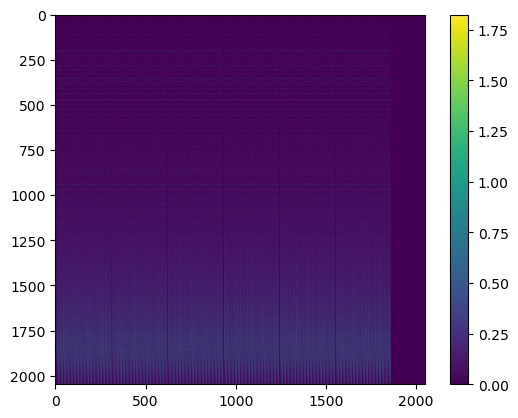

In [64]:
plt.imshow(img_seq_bg[0]/40)
plt.colorbar()
plt.show()

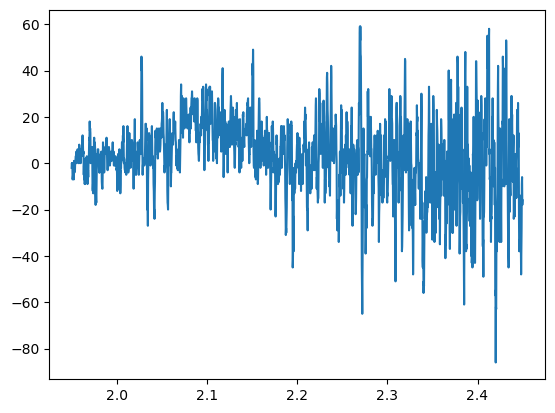

In [59]:
plt.plot(rlams,IFScube_seq[0,:,9,8])
#plt.colorbar()
plt.show()

In [50]:
SNRcube, SNRlist, rlams = sim.point_snr_cube(cube=scene_lowres,nexps=nexps,dit=int_time)

/Users/stephsallum/Sallum Group Dropbox/Steph Sallum/scalesETC_dev/scalesETC/targs.py:238: RuntimeWarning: invalid value encountered in divide
  snrcube = signal_cube/np.sqrt(signal_cube+bkg_cube)


In [51]:
SNRcube.shape

(1, 1900, 18, 17)

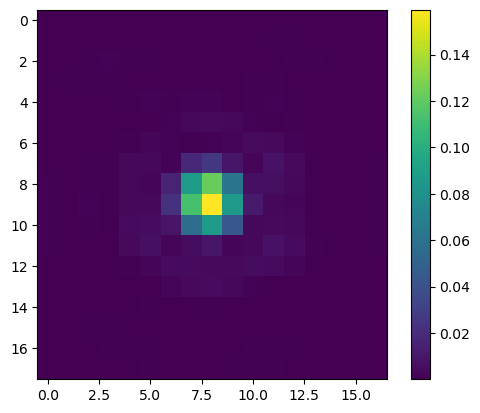

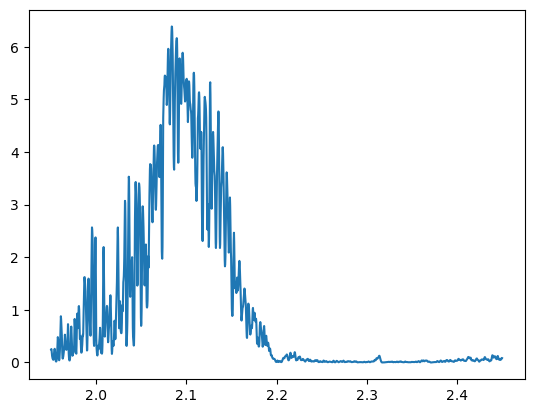

In [52]:
plt.imshow(SNRcube[0][0])
plt.colorbar()
plt.show()

plt.plot(rlams,SNRlist[0])
plt.show()